Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Flattened training data: (60000, 784)

TRAINING VAE
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - kl_loss: 9.8955 - loss: 320.2508 - reconstruction_loss: 310.3556 
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: 6.7209 - loss: 283.9167 - reconstruction_loss: 277.1957
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 6.2968 - loss: 279.5523 - reconstruction_loss: 273.2554
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - kl_loss: 6.1626 - loss: 277.0052 - reconstruction_loss: 270.8425
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 6.1394 - loss: 274.9451 - reconstruction_loss: 268.8057
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 6.1884 - loss: 272.9667 - reconstruction_loss: 266.7785
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 6.2557 - loss: 271.4685 - reconstruction_loss: 265.2128
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━

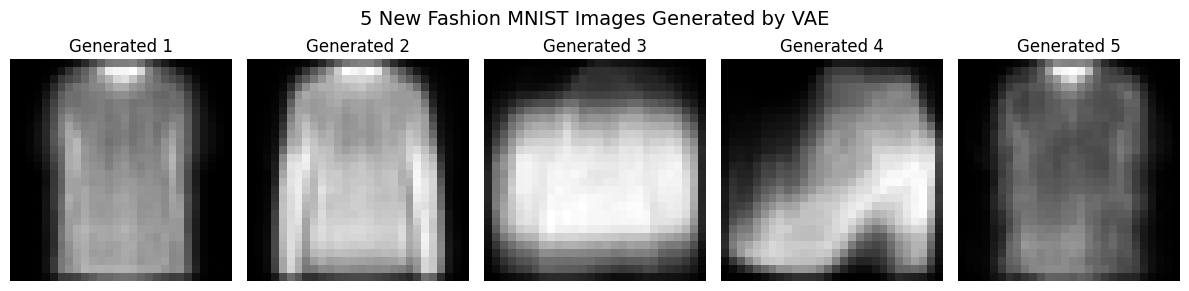

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# ============================================================
# 1. LOAD FASHION MNIST DATASET
# ============================================================

(x_train, _), (x_test, _) = keras.datasets.fashion_mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)


# ============================================================
# 2. NORMALIZE PIXEL VALUES
# ============================================================

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


# ============================================================
# 3. FLATTEN 28x28 IMAGES INTO 784 VALUES
# ============================================================

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Flattened training data:", x_train.shape)


# ============================================================
# 4. VAE PARAMETERS
# ============================================================

input_dim = 784
latent_dim = 2


# ============================================================
# 5. BUILD ENCODER
# ============================================================

encoder_inputs = keras.Input(shape=(input_dim,))

x = layers.Dense(
    128,
    activation="relu"
)(encoder_inputs)

# Mean of latent distribution
z_mean = layers.Dense(
    latent_dim,
    name="z_mean"
)(x)

# Log variance of latent distribution
z_log_var = layers.Dense(
    latent_dim,
    name="z_log_var"
)(x)


# ============================================================
# 6. SAMPLING LAYER
# ============================================================

class Sampling(layers.Layer):

    def call(self, inputs):

        z_mean, z_log_var = inputs

        # Random normal noise
        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        # Reparameterization trick
        z = (
            z_mean
            + tf.exp(0.5 * z_log_var) * epsilon
        )

        return z


# Sample latent vector
z = Sampling()(
    [z_mean, z_log_var]
)


# Complete encoder
encoder = keras.Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)


# ============================================================
# 7. BUILD DECODER
# ============================================================

latent_inputs = keras.Input(
    shape=(latent_dim,)
)

x = layers.Dense(
    128,
    activation="relu"
)(latent_inputs)

decoder_outputs = layers.Dense(
    784,
    activation="sigmoid"
)(x)


# Complete decoder
decoder = keras.Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)


# ============================================================
# 8. BUILD VAE
# ============================================================

class VAE(keras.Model):

    def __init__(
        self,
        encoder,
        decoder,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = keras.metrics.Mean(
            name="total_loss"
        )

        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):

        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):

        # Get input images
        if isinstance(data, tuple):
            data = data[0]

        # ====================================================
        # GradientTape
        # ====================================================

        with tf.GradientTape() as tape:

            # Encode
            z_mean, z_log_var, z = self.encoder(
                data
            )

            # Decode
            reconstruction = self.decoder(z)

            # =================================================
            # RECONSTRUCTION LOSS
            # =================================================

            # Binary crossentropy returns one value per sample.
            # Therefore, DO NOT use axis=1 here.
            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(
                    data,
                    reconstruction
                )
            )

            # Multiply by 784 so the reconstruction loss is
            # on a scale comparable to the KL loss.
            reconstruction_loss = (
                reconstruction_loss * 784.0
            )

            # =================================================
            # KL DIVERGENCE LOSS
            # =================================================

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1
                    + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            # =================================================
            # TOTAL LOSS
            # =================================================

            total_loss = (
                reconstruction_loss
                + kl_loss
            )

        # ====================================================
        # CALCULATE GRADIENTS
        # ====================================================

        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        # ====================================================
        # UPDATE WEIGHTS
        # ====================================================

        self.optimizer.apply_gradients(
            zip(
                gradients,
                self.trainable_weights
            )
        )

        # ====================================================
        # UPDATE METRICS
        # ====================================================

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }


# ============================================================
# 9. CREATE VAE
# ============================================================

vae = VAE(
    encoder,
    decoder
)


# ============================================================
# 10. COMPILE VAE
# ============================================================

vae.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    )
)


# ============================================================
# 11. TRAIN VAE
# ============================================================

print("\n==============================")
print("TRAINING VAE")
print("==============================")

vae.fit(
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True
)


# ============================================================
# 12. SAMPLE 5 RANDOM POINTS FROM LATENT SPACE
# ============================================================

print("\n==============================")
print("SAMPLING LATENT SPACE")
print("==============================")

# Generate 5 random points from a standard normal distribution
random_latent_points = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=(5, latent_dim)
).astype("float32")

print("\nRandom latent points:")
print(random_latent_points)


# ============================================================
# 13. GENERATE NEW IMAGES USING THE DECODER
# ============================================================

generated_images = decoder.predict(
    random_latent_points
)


# ============================================================
# 14. DISPLAY 5 GENERATED IMAGES
# ============================================================

plt.figure(figsize=(12, 3))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(
        generated_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Generated {i + 1}"
    )

    plt.axis("off")


plt.suptitle(
    "5 New Fashion MNIST Images Generated by VAE",
    fontsize=14
)

plt.tight_layout()
plt.show()